In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset('iris')

In [ ]:
print(df.info())
print(df.isna().sum())
num_cols = ['sepal_length', 'sepal_width', 'petal_length']
df_num = df[num_cols]
df_num.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


,sepal_length,sepal_width,petal_length
count,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000
std,0.828066,0.435866,1.765298
min,4.300000,2.000000,1.000000
25%,5.100000,2.800000,1.600000
50%,5.800000,3.000000,4.350000
75%,6.400000,3.300000,5.100000
max,7.900000,4.400000,6.900000


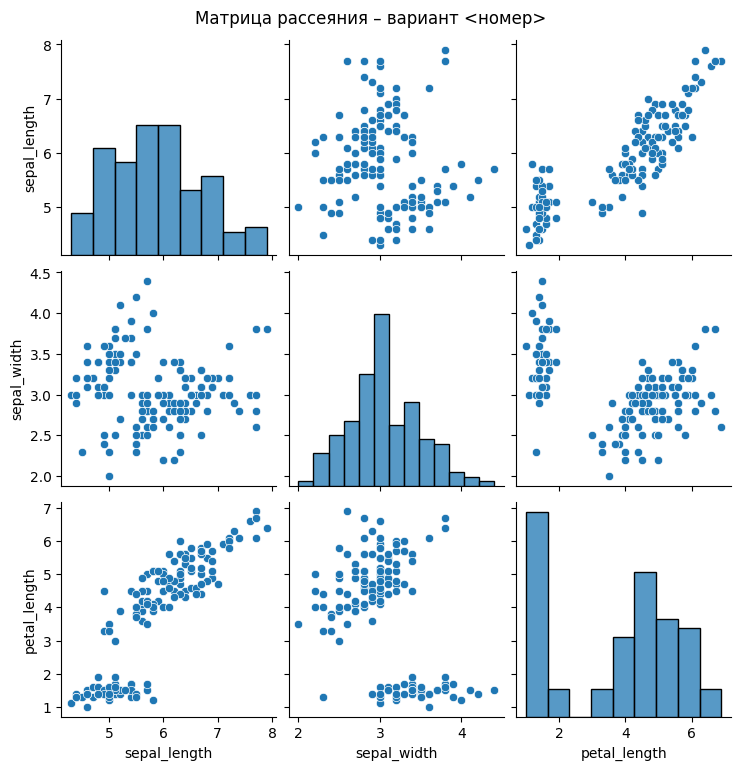

In [ ]:
sns.pairplot(df_num)
plt.suptitle('Матрица рассеяния – вариант <номер>', y=1.02)
plt.savefig('pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

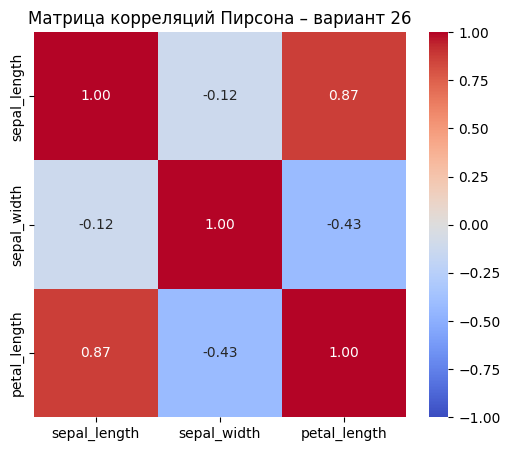

In [ ]:
corr_matrix = df_num.corr(method='pearson')
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляций Пирсона – вариант 26')
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from itertools import combinations
from scipy import stats
import pandas as pd

results = []
for c1, c2 in combinations(num_cols, 2):
    r_p, p_p = stats.pearsonr(df_num[c1], df_num[c2])
    r_s, p_s = stats.spearmanr(df_num[c1], df_num[c2])
    results.append({
        'Пара признаков': f'{c1} — {c2}',
        'Пирсон r': round(r_p, 3),
        'p-value (Пирсон)': round(p_p, 4),
        'Спирмен ρ': round(r_s, 3),
        'p-value (Спирмен)': round(p_s, 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

             Пара признаков  Пирсон r  p-value (Пирсон)  Спирмен ρ  p-value (Спирмен)
 sepal_length — sepal_width    -0.118            0.1519     -0.167             0.0414
sepal_length — petal_length     0.872            0.0000      0.882             0.0000
 sepal_width — petal_length    -0.428            0.0000     -0.310             0.0001


In [ ]:
alpha = 0.05
for row in results:
    sig = 'значима' if row['p-value (Пирсон)'] < alpha else 'НЕ значима'
    print(f"{row['Пара признаков']}: корреляция Пирсона {sig} (p={row['p-value (Пирсон)']})")
    bet = 'значима' if row['p-value (Спирмен)'] < alpha else 'НЕ значима'
    print(f"{row['Пара признаков']}: корреляция Спирмена {bet} (p={row['p-value (Спирмен)']})")



sepal_length — sepal_width: корреляция Пирсона НЕ значима (p=0.1519)
sepal_length — sepal_width: корреляция Спирмена значима (p=0.0414)
sepal_length — petal_length: корреляция Пирсона значима (p=0.0)
sepal_length — petal_length: корреляция Спирмена значима (p=0.0)
sepal_width — petal_length: корреляция Пирсона значима (p=0.0)
sepal_width — petal_length: корреляция Спирмена значима (p=0.0001)
